In [1]:
sharpe_ratio = (0.35 - 0.05)/0.25
print(sharpe_ratio)

1.2


In [4]:
alpha = (0.3 - (1.2 * 0.2)) * 100
print(alpha)

6.0


In [5]:
import yfinance as yf

btc = yf.download("BTC-USD", start="2020-01-01", end="2025-12-31")
btc.columns = btc.columns.droplevel(1)  
print(btc.head())     # first 5 rows
print(btc.tail())     # last 5 rows
print(btc.shape)      # (rows, columns)
print(btc.info())     # column types, missing values
print(btc.describe()) # mean, std, min, max, quartiles

/var/folders/x7/_9kdc2hd3g3d62j28dsz3nx40000gn/T/ipykernel_22759/1279041349.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2020-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open       Volume
Date                                                                       
2020-01-01  7200.174316  7254.330566  7174.944336  7194.892090  18565664997
2020-01-02  6985.470215  7212.155273  6935.270020  7202.551270  20802083465
2020-01-03  7344.884277  7413.715332  6914.996094  6984.428711  28111481032
2020-01-04  7410.656738  7427.385742  7309.514160  7345.375488  18444271275
2020-01-05  7411.317383  7544.497070  7400.535645  7410.451660  19725074095
Price              Close          High           Low          Open  \
Date                                                                 
2025-12-26  87301.429688  89459.429688  86628.140625  87235.507812   
2025-12-27  87802.156250  87874.781250  87182.976562  87301.429688   
2025-12-28  87835.835938  87986.890625  87394.953125  87799.343750   
2025-12-29  87138.140625  90299.156250  86717.914062  87835.789062   
2025-12-30  88430.132812  89297.937500  86735.54

In [8]:
import numpy as np
risk_free_daily = 0.05/ 365

btc["returns"] = btc["Close"].pct_change()

sharpe_full = ((btc["returns"].mean() - risk_free_daily)/ btc["returns"].std()) * np.sqrt(365)
print(sharpe_full)

0.9140000164390034


Simple return = (today - yesterday) / yesterday
BTC goes from $60,000 to $63,000. Simple return = 3,000 / 60,000 = 5%.

Log return = ln(today / yesterday)
Same move: ln(63,000 / 60,000) = ln(1.05) = 4.88%.

Why quants prefer log returns — one reason that matters:
They're additive. If Monday's log return is +2% and Tuesday's log return is -1%, the total two-day log return is exactly +1%. Just add them.
Simple returns don't work this way. Monday: BTC at $100, goes to $102 (+2%). Tuesday: $102 drops to $100.98 (-1%). Two-day simple return: ($100.98 - $100) / $100 = 0.98%. Not 1%. Close but wrong. The error compounds over hundreds of trades.
For a scalper making 50 trades a day, these tiny errors accumulate. Log returns keep the math clean.


In [11]:
import numpy as np

# These two are equivalent
simple_return = (63000 - 60000) / 60000        # 0.05
log_return = np.log(63000 / 60000)              # 0.04879

# Convert between them
log_from_simple = np.log(1 + simple_return)     # 0.04879
simple_from_log = np.exp(log_return) - 1        # 0.05

In [15]:
# Simple returns — what you've been doing
btc["simple_returns"] = btc["Close"].pct_change()

# Log returns — the quant way
btc["log_returns"] = np.log(btc["Close"] / btc["Close"].shift(1))

# Compare them
print(btc[["Close","simple_returns", "log_returns"]].loc['2020-03'])

Price             Close  simple_returns  log_returns
Date                                                
2020-03-01  8562.454102       -0.004309    -0.004318
2020-03-02  8869.669922        0.035879     0.035251
2020-03-03  8787.786133       -0.009232    -0.009275
2020-03-04  8755.246094       -0.003703    -0.003710
2020-03-05  9078.762695        0.036951     0.036285
2020-03-06  9122.545898        0.004823     0.004811
2020-03-07  8909.954102       -0.023304    -0.023580
2020-03-08  8108.116211       -0.089993    -0.094304
2020-03-09  7923.644531       -0.022751    -0.023014
2020-03-10  7909.729492       -0.001756    -0.001758
2020-03-11  7911.430176        0.000215     0.000215
2020-03-12  4970.788086       -0.371695    -0.464730
2020-03-13  5563.707031        0.119281     0.112686
2020-03-14  5200.366211       -0.065306    -0.067536
2020-03-15  5392.314941        0.036911     0.036246
2020-03-16  5014.479980       -0.070069    -0.072645
2020-03-17  5225.629395        0.042108     0.

In [17]:
# Monthly average returns
monthly = btc["log_returns"].groupby(btc.index.to_period("M")).sum()
print(monthly.head(12))

Date
2020-01    0.261328
2020-02   -0.083728
2020-03   -0.289387
2020-04    0.296230
2020-05    0.088637
2020-06   -0.034743
2020-07    0.214436
2020-08    0.031071
2020-09   -0.079839
2020-10    0.245181
2020-11    0.353556
2020-12    0.390508
Freq: M, Name: log_returns, dtype: float64


In [18]:
# Yearly returns
yearly = btc["log_returns"].groupby(btc.index.year).sum()
print(yearly)

Date
2020    1.393250
2021    0.467926
2022   -1.029046
2023    0.937729
2024    0.793240
2025   -0.054991
Name: log_returns, dtype: float64


In [19]:
# Monthly stats — mean, std, min, max in one call
monthly_stats = btc["log_returns"].groupby(btc.index.to_period("M")).agg(
    ["mean", "std", "min", "max", "count"]
)
print(monthly_stats.head(12))

             mean       std       min       max  count
Date                                                  
2020-01  0.008711  0.028110 -0.032115  0.080597     30
2020-02 -0.002887  0.025718 -0.057408  0.046028     29
2020-03 -0.009335  0.101122 -0.464730  0.167104     31
2020-04  0.009874  0.034906 -0.061653  0.119841     30
2020-05  0.002859  0.033651 -0.091339  0.071075     31
2020-06 -0.001158  0.024291 -0.064749  0.071989     30
2020-07  0.006917  0.021541 -0.016077  0.104009     31
2020-08  0.001002  0.022795 -0.061912  0.047160     31
2020-09 -0.002661  0.029168 -0.108025  0.048936     30
2020-10  0.007909  0.018735 -0.028446  0.073384     31
2020-11  0.011785  0.036159 -0.088205  0.097416     30
2020-12  0.012597  0.033161 -0.046418  0.093052     31


In [20]:
# Find the worst month
worst_month = monthly.idxmin()
worst_return = monthly.min()
print(f"Worst month: {worst_month}, return: {worst_return:.2%}")

# Find the best month
best_month = monthly.idxmax()
best_return = monthly.max()
print(f"Best month: {best_month}, return: {best_return:.2%}")

Worst month: 2022-06, return: -47.43%
Best month: 2020-12, return: 39.05%


In [23]:
weekly = btc["log_returns"].groupby(btc.index.to_period("W")).sum()
print(weekly.head(10))

weekly_stats = btc["log_returns"].groupby(btc.index.to_period("W")).agg(
    ["mean", "std", "min", "max", "count"]
)
print(weekly_stats)

worst_week = weekly.idxmin()
worst_return = weekly.min()
print(worst_week, worst_return)

Date
2019-12-30/2020-01-05    0.028903
2020-01-06/2020-01-12    0.100210
2020-01-13/2020-01-19    0.060822
2020-01-20/2020-01-26   -0.012647
2020-01-27/2020-02-02    0.083380
2020-02-03/2020-02-09    0.079411
2020-02-10/2020-02-16   -0.018178
2020-02-17/2020-02-23   -0.000999
2020-02-24/2020-03-01   -0.147621
2020-03-02/2020-03-08   -0.054521
Freq: W-SUN, Name: log_returns, dtype: float64
                           mean       std       min       max  count
Date                                                                
2019-12-30/2020-01-05  0.007226  0.033188 -0.030273  0.050172      4
2020-01-06/2020-01-12  0.014316  0.031318 -0.025165  0.049527      7
2020-01-13/2020-01-19  0.008689  0.035024 -0.026809  0.080597      7
2020-01-20/2020-01-26 -0.001807  0.018411 -0.032115  0.026997      7
2020-01-27/2020-02-02  0.011911  0.024041 -0.016805  0.049141      7
...                         ...       ...       ...       ...    ...
2025-12-01/2025-12-07  0.000018  0.034619 -0.046102  0.0

ROLLING STATISTICS — VOLATILITY CHANGES OVER TIME
What goes wrong if you don't know this:
Your bot calculates volatility using the entire dataset. It gets 3% daily std. It sizes positions based on that. But RIGHT NOW, volatility is 1.5%. Your bot is being too conservative — it's sizing positions for 3% swings when the market is calm. You're leaving money on the table.
Next week, volatility spikes to 6%. Your bot is still sizing for 3%. Now it's too aggressive — taking positions twice as large as it should for the current conditions. You get crushed.
Rolling statistics solve this. Instead of calculating one number from all history, you calculate from a moving window — the last 30 days, the last 7 days. The number updates every day, tracking current conditions.

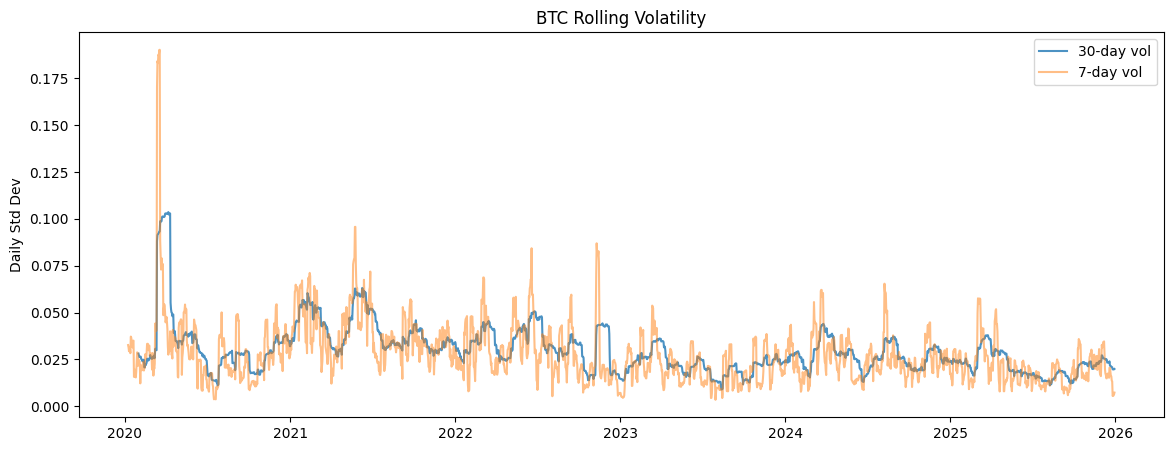

In [24]:
# Rolling 30-day volatility
btc["rolling_vol_30"] = btc["log_returns"].rolling(window=30).std()

# Rolling 7-day volatility (more responsive, noisier)
btc["rolling_vol_7"] = btc["log_returns"].rolling(window=7).std()

# Plot both
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(btc.index, btc["rolling_vol_30"], label="30-day vol", alpha=0.8)
plt.plot(btc.index, btc["rolling_vol_7"], label="7-day vol", alpha=0.5)
plt.title("BTC Rolling Volatility")
plt.ylabel("Daily Std Dev")
plt.legend()
plt.show()

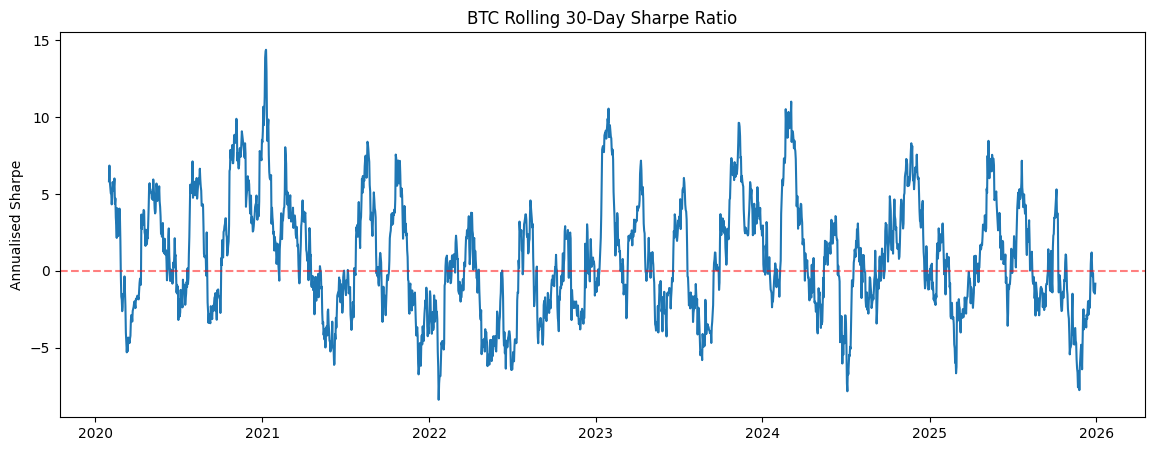

In [25]:
# Rolling 30-day mean return
btc["rolling_mean_30"] = btc["log_returns"].rolling(window=30).mean()

# Rolling Sharpe (30-day)
risk_free_daily = 0.05 / 365
btc["rolling_sharpe_30"] = (
    (btc["rolling_mean_30"] - risk_free_daily) / btc["rolling_vol_30"]
) * (365 ** 0.5)

plt.figure(figsize=(14, 5))
plt.plot(btc.index, btc["rolling_sharpe_30"])
plt.axhline(y=0, color="red", linestyle="--", alpha=0.5)
plt.title("BTC Rolling 30-Day Sharpe Ratio")
plt.ylabel("Annualised Sharpe")
plt.show()

In [27]:
btc["rolling_vol_30"] = btc["log_returns"].rolling(window=30).std()

1. Simple returns tells you the normal percentage gain or loss. while log returns the compound changes. Quant prefer log returns is because it can be added instead of multiplied

2. Rolling sharpe is sharpe ratio calculated over a moving window. It needs to see whethere its risk adjusted is still strong now instead of looking good only on historical averages - daily health check



In [28]:
daily_mean = 0.0005     # 0.05%
daily_std = 0.025       # 2.5%
risk_free = 0.05        # 5% annual

annual_return = daily_mean * 365
annual_vol = daily_std * (365 ** 0.5)
annual_sharpe = (annual_return - risk_free) / annual_vol

print(f"Annual return: {annual_return:.2%}")
print(f"Annual vol: {annual_vol:.2%}")
print(f"Annual Sharpe: {annual_sharpe:.2f}")

Annual return: 18.25%
Annual vol: 47.76%
Annual Sharpe: 0.28


In [31]:
# Exercise 1: Calculate the rolling 30-day Sharpe for BTC. 
# Find the worst 30-day period. What was happening in the market at that time?

btc["rolling_mean_30"] = btc["log_returns"].rolling(window=30).mean()
btc["rolling_vol_30"] = btc["log_returns"].rolling(window=30).std()


risk_free_daily = 0.05/365
btc["rolling_sharpe_30"] = (
    (btc["rolling_mean_30"] - risk_free_daily)/ btc["rolling_vol_30"]
) * (365 ** 0.5)

worst_date = btc["rolling_sharpe_30"].idxmin()
btc.loc[worst_date]


Price
Close                3.503025e+04
High                 3.668881e+04
Low                  3.434925e+04
Open                 3.647159e+04
Volume               3.971439e+10
returns             -3.914348e-02
simple_returns      -3.914348e-02
log_returns         -3.993019e-02
rolling_vol_30       2.850918e-02
rolling_vol_7        3.801982e-02
rolling_mean_30     -1.237933e-02
rolling_sharpe_30   -8.387612e+00
Name: 2022-01-22 00:00:00, dtype: float64

In [36]:
daily_returns = [0.003, -0.001, 0.004, -0.002, 0.002, -0.003, 0.005, 0.001, -0.001, 0.003]

daily_mean = np.mean(daily_returns)
daily_std = np.std(daily_returns, ddof=1)

risk_free_daily = 0.05/ 365
sharpe_daily = (daily_mean - risk_free_daily)/ daily_std
sharpe_annual = sharpe_daily * (365 ** 0.5)

In [3]:
# Quant Question: BTC has daily log returns with mean 0.05% and std 2.5%. 
# What is the annualised return? 
# What is annualised volatility? 
# What is the Sharpe assuming 5% risk-free?
import numpy as np

daily_mean = 0.0005
std = 0.025
risk_free_rate = 0.05
no_trades = 365

annualised_log_return = daily_mean * no_trades
annualised_simple_return = np.exp(annualised_log_return) - 1
annualised_vol = std * np.sqrt(no_trades)

sharpe = (annualised_log_return - risk_free_rate)/ annualised_vol
print(annualised_log_return)
print(annualised_simple_return)
print(annualised_vol)
print(sharpe)


0.1825
0.20021415095357753
0.47762432936357
0.27741467897281324
